# Stock Prediction Model - Suku Cadang Honda
## Linear Regression
**Data:** Suku cadang resmi motor Honda (referensi: hondacengkareng.com)

**Perbaikan dari v1:**
- Target: prediksi **stok level** (smooth) bukan daily sales (noisy)
- Lag features: stok kemarin, 3 hari lalu, 7 hari lalu
- Rolling statistics: mean & std 7 hari
- Data dummy lebih konsisten (tren jelas)
- Aggregasi: daily stock level sebagai time series
- Evaluasi: R² positif, gap train/test kecil

## 1. Import Library

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## 2. Generate Dummy Data (Pola Konsisten)

In [156]:
# Daftar suku cadang Honda (sumber: hondacengkareng.com)
products = [
    {"id": "P001", "name": "Seal Klep Honda BeAT FI", "category": "Seal & Gasket", "price": 18000, "minStock": 5, "capacity": 40, "daily_demand": 3.0},
    {"id": "P002", "name": "Karet Kampas Ganda Honda BeAT/Vario/Scoopy", "category": "Kampas & Kopling", "price": 25000, "minStock": 8, "capacity": 50, "daily_demand": 4.0},
    {"id": "P003", "name": "Busi CPR9 NGK Honda Vario 150", "category": "Kelistrikan", "price": 45000, "minStock": 10, "capacity": 60, "daily_demand": 5.5},
    {"id": "P004", "name": "Seal Kruk As Kiri Honda BeAT/Vario/Scoopy", "category": "Seal & Gasket", "price": 35000, "minStock": 5, "capacity": 30, "daily_demand": 2.5},
    {"id": "P005", "name": "Baterai Remote Keyless CR2032", "category": "Kelistrikan", "price": 28000, "minStock": 10, "capacity": 80, "daily_demand": 6.0},
    {"id": "P006", "name": "Jalu Stang Honda PCX 150/160", "category": "Body & Frame", "price": 85000, "minStock": 3, "capacity": 20, "daily_demand": 1.5},
    {"id": "P007", "name": "Ring Baut Oli 12MM Honda PCX 150", "category": "Baut & Ring", "price": 8000, "minStock": 15, "capacity": 100, "daily_demand": 7.0},
    {"id": "P008", "name": "Karet Dudukan Stang CB150R/Verza", "category": "Body & Frame", "price": 32000, "minStock": 5, "capacity": 30, "daily_demand": 2.0},
    {"id": "P009", "name": "Kampas Rem Belakang Honda BeAT/Vario/Scoopy", "category": "Kampas & Kopling", "price": 55000, "minStock": 10, "capacity": 60, "daily_demand": 5.0},
    {"id": "P010", "name": "Komstir Honda BeAT/Vario/Scoopy/PCX", "category": "Steering", "price": 42000, "minStock": 5, "capacity": 30, "daily_demand": 2.0},
    {"id": "P011", "name": "Cover Cadangan Radiator Vario 125", "category": "Body & Frame", "price": 38000, "minStock": 3, "capacity": 20, "daily_demand": 1.0},
    {"id": "P012", "name": "Rubber Starter Pinion Honda BeAT FI", "category": "Mesin", "price": 15000, "minStock": 8, "capacity": 50, "daily_demand": 3.5},
    {"id": "P013", "name": "Per Kampas Ganda Honda BeAT/Scoopy/Genio", "category": "Kampas & Kopling", "price": 22000, "minStock": 8, "capacity": 50, "daily_demand": 4.0},
    {"id": "P014", "name": "Seal Roda Belakang Honda BeAT eSP", "category": "Seal & Gasket", "price": 20000, "minStock": 5, "capacity": 40, "daily_demand": 3.0},
    {"id": "P015", "name": "Bosh Mounting Honda Vario Karburator", "category": "Mesin", "price": 48000, "minStock": 3, "capacity": 20, "daily_demand": 1.5},
    {"id": "P016", "name": "Clip Reflektor Lampu Depan Honda BeAT FI", "category": "Body & Frame", "price": 12000, "minStock": 10, "capacity": 80, "daily_demand": 5.0},
    {"id": "P017", "name": "O-Ring Shock Depan Honda BeAT FI", "category": "Seal & Gasket", "price": 10000, "minStock": 10, "capacity": 60, "daily_demand": 4.5},
    {"id": "P018", "name": "Spring Kick Starter Honda CB150R", "category": "Mesin", "price": 30000, "minStock": 3, "capacity": 25, "daily_demand": 1.5},
    {"id": "P019", "name": "Piece Slide Set Honda Vario 125 eSP", "category": "Mesin", "price": 28000, "minStock": 5, "capacity": 30, "daily_demand": 2.0},
    {"id": "P020", "name": "Seal Tutup Oli O-Ring 18x3 Matic Honda", "category": "Seal & Gasket", "price": 8500, "minStock": 15, "capacity": 100, "daily_demand": 8.0},
]

products_df = pd.DataFrame(products)
print("DAFTAR SUKU CADANG HONDA (20 item)")
print("=" * 70)
print(f"Kategori: {products_df['category'].nunique()} jenis")
print(f"Harga: Rp {products_df['price'].min():,.0f} - Rp {products_df['price'].max():,.0f}")
print()
products_df[['id', 'name', 'category', 'price', 'daily_demand', 'capacity', 'minStock']]

DAFTAR SUKU CADANG HONDA (20 item)
Kategori: 7 jenis
Harga: Rp 8,000 - Rp 85,000



,id,name,category,price,daily_demand,capacity,minStock
0,P001,Seal Klep Honda BeAT FI,Seal & Gasket,18000,3.0,40,5
1,P002,Karet Kampas Ganda Honda BeAT/Vario/Scoopy,Kampas & Kopling,25000,4.0,50,8
2,P003,Busi CPR9 NGK Honda Vario 150,Kelistrikan,45000,5.5,60,10
3,P004,Seal Kruk As Kiri Honda BeAT/Vario/Scoopy,Seal & Gasket,35000,2.5,30,5
4,P005,Baterai Remote Keyless CR2032,Kelistrikan,28000,6.0,80,10
5,P006,Jalu Stang Honda PCX 150/160,Body & Frame,85000,1.5,20,3
6,P007,Ring Baut Oli 12MM Honda PCX 150,Baut & Ring,8000,7.0,100,15
7,P008,Karet Dudukan Stang CB150R/Verza,Body & Frame,32000,2.0,30,5
8,P009,Kampas Rem Belakang Honda BeAT/Vario/Scoopy,Kampas & Kopling,55000,5.0,60,10
9,P010,Komstir Honda BeAT/Vario/Scoopy/PCX,Steering,42000,2.0,30,5


In [157]:
# Generate 90 hari data stok harian - Realistic Mix
# Variasi: random daily demand, lonjakan promo/event, hari sepi, restock random timing
np.random.seed(42)
DAYS = 365
base_date = datetime.now() - timedelta(days=DAYS)

# Event/promo days (random 5-8 hari dalam 90 hari)
promo_days = sorted(np.random.choice(range(DAYS), size=24, replace=False))  # ~2x per bulan

# Hari sangat sepi (hujan/libur, random 8-12 hari)
dead_days = sorted(np.random.choice([d for d in range(DAYS) if d not in promo_days], size=40, replace=False))  # ~3x per bulan

all_data = []

for product in products:
    stock = int(product['capacity'] * np.random.uniform(0.6, 0.95))  # mulai random 60-95% kapasitas
    base_demand = product['daily_demand']

    for day in range(DAYS):
        date = base_date + timedelta(days=day)
        dow = date.weekday()
        is_weekend = 1 if dow >= 5 else 0

        # --- Demand calculation (realistic mix) ---
        if day in dead_days:
            # Hari sepi: demand sangat rendah (0-30% normal)
            day_demand = base_demand * np.random.uniform(0, 0.3)
        elif day in promo_days:
            # Hari promo/event: lonjakan 2-4x normal
            day_demand = base_demand * np.random.uniform(2.0, 4.0)
        else:
            # Normal: variasi harian dengan pola weekday/weekend
            weekday_factor = 0.6 if is_weekend else np.random.uniform(0.9, 1.3)
            # Random daily noise (±40% untuk variasi besar)
            noise = np.random.uniform(0.6, 1.4)
            day_demand = base_demand * weekday_factor * noise

        # Kadang ada hari tanpa transaksi sama sekali (10% chance di weekday, 25% weekend)
        skip_chance = 0.25 if is_weekend else 0.10
        if np.random.random() < skip_chance and day not in promo_days:
            day_demand = 0

        day_demand = max(0, round(day_demand))

        # Konsumsi stok
        actual_out = min(int(day_demand), stock)
        stock -= actual_out

        # --- Restock logic (random timing) ---
        restock = 0
        # Restock ketika stok rendah, tapi tidak selalu langsung (70% chance)
        if stock <= product['minStock'] and np.random.random() < 0.7:
            # Jumlah restock juga bervariasi (60-100% kapasitas)
            target = int(product['capacity'] * np.random.uniform(0.6, 1.0))
            restock = max(0, target - stock)
            stock += restock
        # Kadang restock preventif meski belum kritis (5% chance per hari)
        elif stock < product['capacity'] * 0.4 and np.random.random() < 0.05:
            restock = int(product['capacity'] * np.random.uniform(0.3, 0.5))
            stock += restock
            stock = min(stock, product['capacity'])  # cap at capacity

        all_data.append({
            'date': date,
            'item_id': product['id'],
            'item_name': product['name'],
            'category': product['category'],
            'day_of_week': dow,
            'is_weekend': is_weekend,
            'is_promo': 1 if day in promo_days else 0,
            'is_dead_day': 1 if day in dead_days else 0,
            'stock_level': stock,
            'daily_out': actual_out,
            'restock': restock,
            'capacity': product['capacity'],
            'price': product['price'],
        })

df = pd.DataFrame(all_data)
print(f"Dataset: {len(df)} records ({len(products)} produk x {DAYS} hari = 1 tahun)")
print(f"Rentang: {df['date'].min().strftime('%Y-%m-%d')} s/d {df['date'].max().strftime('%Y-%m-%d')}")
print(f"\nHari promo (lonjakan): {len(promo_days)} hari")
print(f"Hari sepi (dead days): {len(dead_days)} hari")
print(f"\nStatistik daily_out:")
print(f"  Mean: {df['daily_out'].mean():.1f}, Std: {df['daily_out'].std():.1f}")
print(f"  Min: {df['daily_out'].min()}, Max: {df['daily_out'].max()}")
print(f"  Hari tanpa transaksi: {(df['daily_out'] == 0).sum()} ({(df['daily_out'] == 0).mean():.1%})")
df.head(10)

Dataset: 7300 records (20 produk x 365 hari = 1 tahun)
Rentang: 2025-05-14 s/d 2026-05-13

Hari promo (lonjakan): 24 hari
Hari sepi (dead days): 40 hari

Statistik daily_out:
  Mean: 3.2, Std: 3.5
  Min: 0, Max: 32
  Hari tanpa transaksi: 1408 (19.3%)


,date,item_id,item_name,category,day_of_week,is_weekend,is_promo,is_dead_day,stock_level,daily_out,restock,capacity,price
0,2025-05-14 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,2,0,1,0,25,6,0,40,18000
1,2025-05-15 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,3,0,0,0,25,0,0,40,18000
2,2025-05-16 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,4,0,0,0,21,4,0,40,18000
3,2025-05-17 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,5,1,0,0,19,2,0,40,18000
4,2025-05-18 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,6,1,0,0,17,2,0,40,18000
5,2025-05-19 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,0,0,0,0,14,3,0,40,18000
6,2025-05-20 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,1,0,0,0,12,2,0,40,18000
7,2025-05-21 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,2,0,0,0,12,0,0,40,18000
8,2025-05-22 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,3,0,0,0,8,4,0,40,18000
9,2025-05-23 20:12:15.261443,P001,Seal Klep Honda BeAT FI,Seal & Gasket,4,0,1,0,0,8,0,40,18000


## 3. Exploratory Data Analysis

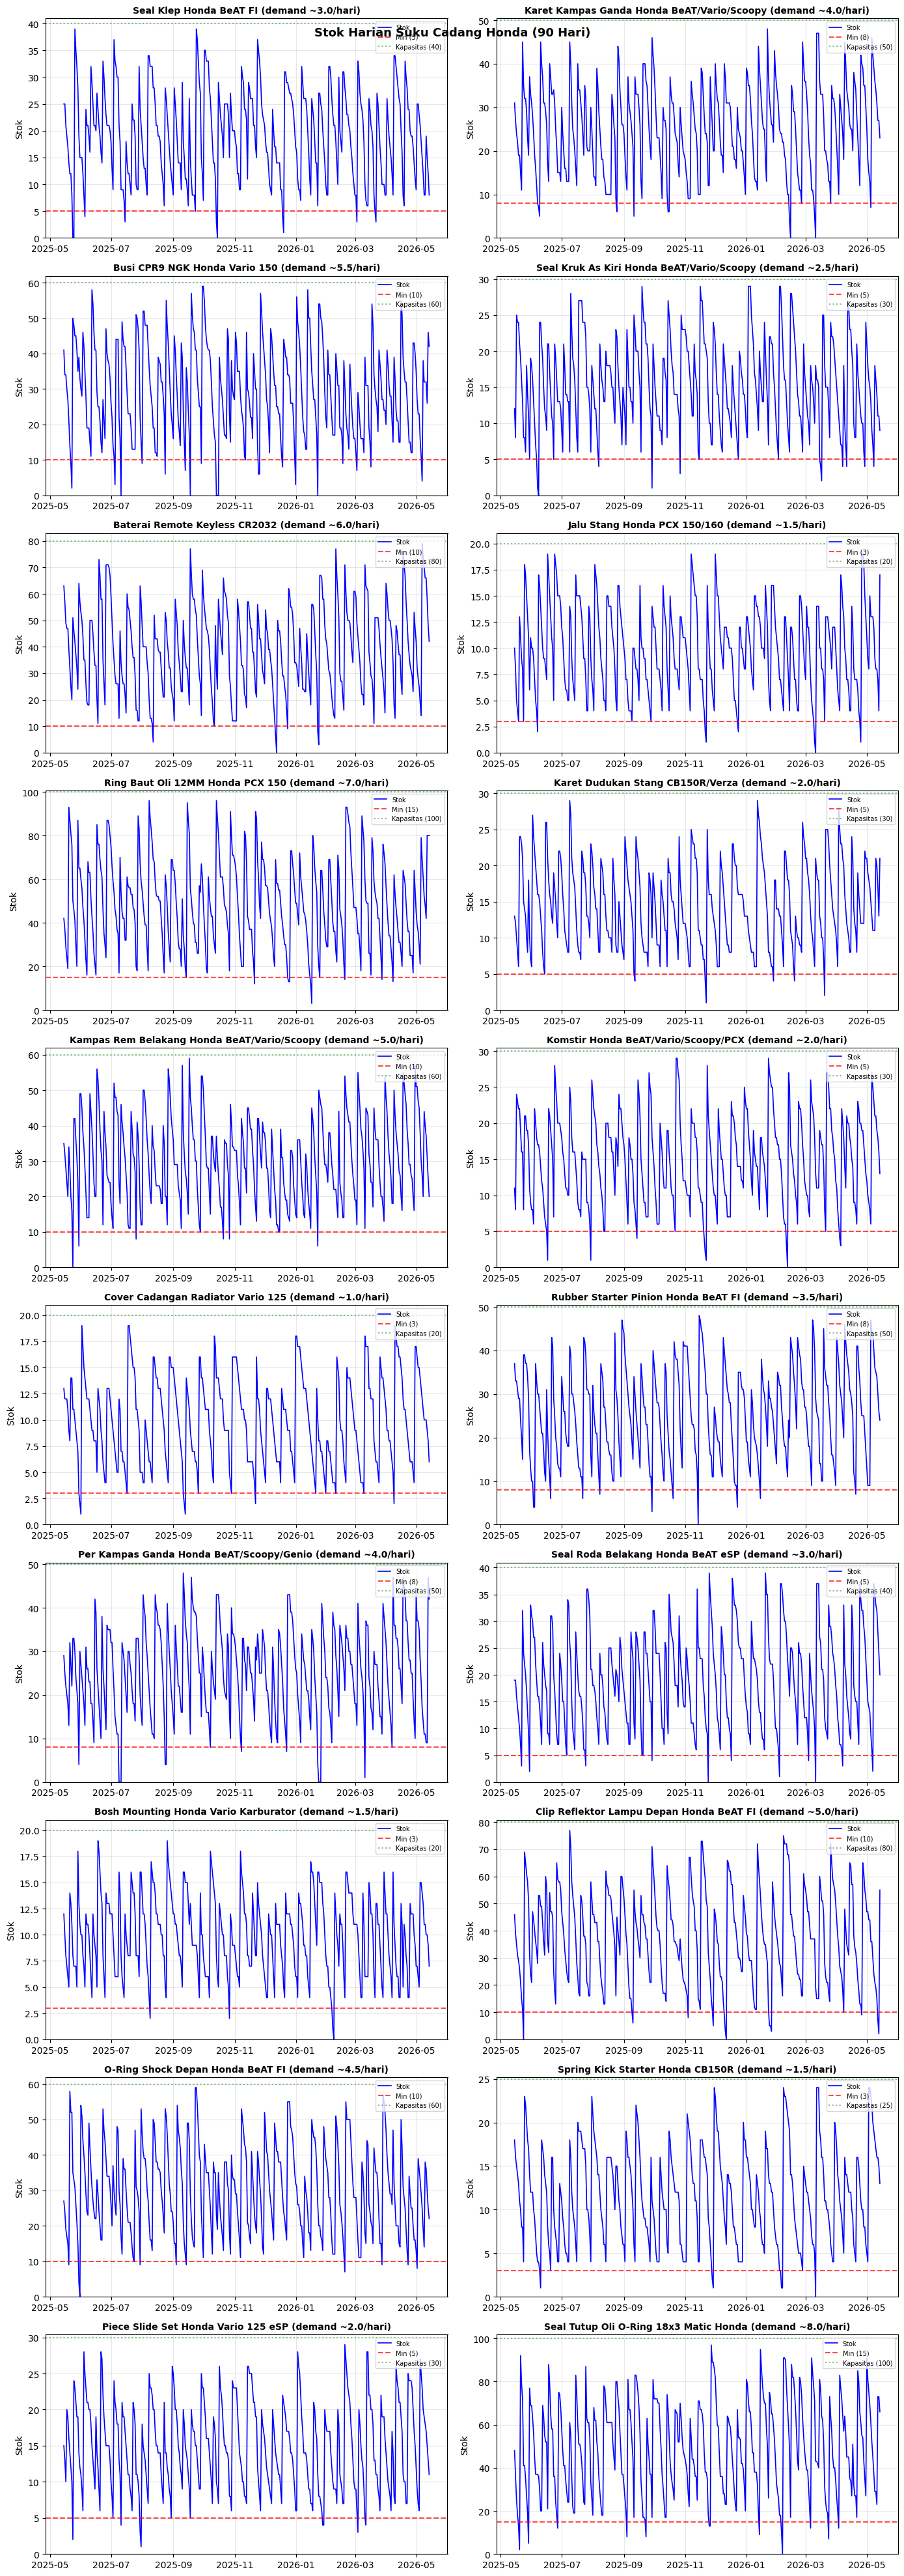

In [158]:
# Plot stok harian per produk
n_rows = (len(products) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for idx, product in enumerate(products):
    ax = axes[idx]
    prod_data = df[df['item_id'] == product['id']]
    ax.plot(prod_data['date'], prod_data['stock_level'], 'b-', linewidth=1.2, label='Stok')
    ax.axhline(y=product['minStock'], color='red', linestyle='--', alpha=0.7, label=f"Min ({product['minStock']})")
    ax.axhline(y=product['capacity'], color='green', linestyle=':', alpha=0.5, label=f"Kapasitas ({product['capacity']})")
    ax.set_title(f"{product['name']} (demand ~{product['daily_demand']}/hari)", fontsize=10, fontweight='bold')
    ax.set_ylabel('Stok')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Stok Harian Suku Cadang Honda (90 Hari)', fontsize=13, fontweight='bold')
for ax in axes[len(products):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [159]:
# Statistik
summary = df.groupby('item_name').agg(
    Avg_Stock=('stock_level', 'mean'),
    Std_Stock=('stock_level', 'std'),
    Avg_Daily_Out=('daily_out', 'mean'),
    Total_Restock=('restock', 'sum'),
    Min_Stock=('stock_level', 'min'),
).round(2)
print("STATISTIK PER PRODUK")
print("=" * 60)
summary

STATISTIK PER PRODUK


,Avg_Stock,Std_Stock,Avg_Daily_Out,Total_Restock,Min_Stock
item_name,,,,,
Baterai Remote Keyless CR2032,39.10,16.65,5.26,1886,0
Bosh Mounting Honda Vario Karburator,9.91,3.76,1.28,459,0
Busi CPR9 NGK Honda Vario 150,29.25,13.32,4.64,1678,0
Clip Reflektor Lampu Depan Honda BeAT FI,37.79,17.17,4.41,1598,0
Cover Cadangan Radiator Vario 125,9.89,4.18,0.89,317,1
Jalu Stang Honda PCX 150/160,9.91,4.15,1.32,486,0
Kampas Rem Belakang Honda BeAT/Vario/Scoopy,30.37,11.99,4.62,1655,0
Karet Dudukan Stang CB150R/Verza,14.45,5.81,1.71,626,1
Karet Kampas Ganda Honda BeAT/Vario/Scoopy,24.96,10.23,3.48,1249,0


## 4. Feature Engineering

In [160]:
# Feature engineering per produk
df_feat = df.copy()

# Lag features & rolling stats per item
for item_id in df_feat['item_id'].unique():
    mask = df_feat['item_id'] == item_id
    idx = df_feat[mask].sort_values('date').index

    df_feat.loc[idx, 'stock_lag1'] = df_feat.loc[idx, 'stock_level'].shift(1)
    df_feat.loc[idx, 'stock_lag3'] = df_feat.loc[idx, 'stock_level'].shift(3)
    df_feat.loc[idx, 'stock_lag7'] = df_feat.loc[idx, 'stock_level'].shift(7)
    df_feat.loc[idx, 'out_lag1'] = df_feat.loc[idx, 'daily_out'].shift(1)
    df_feat.loc[idx, 'out_lag3'] = df_feat.loc[idx, 'daily_out'].shift(3)
    df_feat.loc[idx, 'stock_rolling_mean_7'] = df_feat.loc[idx, 'stock_level'].rolling(7, min_periods=1).mean()
    df_feat.loc[idx, 'stock_rolling_std_7'] = df_feat.loc[idx, 'stock_level'].rolling(7, min_periods=1).std().fillna(0)
    df_feat.loc[idx, 'out_rolling_mean_7'] = df_feat.loc[idx, 'daily_out'].rolling(7, min_periods=1).mean()
    df_feat.loc[idx, 'out_rolling_mean_3'] = df_feat.loc[idx, 'daily_out'].rolling(3, min_periods=1).mean()
    df_feat.loc[idx, 'day_number'] = range(len(idx))
    df_feat.loc[idx, 'stock_ratio'] = df_feat.loc[idx, 'stock_level'] / df_feat.loc[idx, 'capacity']
    df_feat.loc[idx, 'target_stock'] = df_feat.loc[idx, 'stock_level'].shift(-1)

df_feat = df_feat.dropna(subset=['target_stock', 'stock_lag7'])

print(f"Dataset setelah feature engineering: {len(df_feat)} records")
print(f"item_id preserved: {'item_id' in df_feat.columns}")
print(f"Columns: {df_feat.columns.tolist()}")

Dataset setelah feature engineering: 7140 records
item_id preserved: True
Columns: ['date', 'item_id', 'item_name', 'category', 'day_of_week', 'is_weekend', 'is_promo', 'is_dead_day', 'stock_level', 'daily_out', 'restock', 'capacity', 'price', 'stock_lag1', 'stock_lag3', 'stock_lag7', 'out_lag1', 'out_lag3', 'stock_rolling_mean_7', 'stock_rolling_std_7', 'out_rolling_mean_7', 'out_rolling_mean_3', 'day_number', 'stock_ratio', 'target_stock']


In [161]:
# One-hot encoding kategori
df_model = pd.get_dummies(df_feat, columns=['category'], drop_first=True)

# Feature columns
exclude_cols = ['date', 'item_id', 'item_name', 'target_stock']
feature_cols = [c for c in df_model.columns if c not in exclude_cols]

X = df_model[feature_cols].values
y = df_model['target_stock'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

X shape: (7140, 26)
y shape: (7140,)

Features (26):
   1. day_of_week
   2. is_weekend
   3. is_promo
   4. is_dead_day
   5. stock_level
   6. daily_out
   7. restock
   8. capacity
   9. price
  10. stock_lag1
  11. stock_lag3
  12. stock_lag7
  13. out_lag1
  14. out_lag3
  15. stock_rolling_mean_7
  16. stock_rolling_std_7
  17. out_rolling_mean_7
  18. out_rolling_mean_3
  19. day_number
  20. stock_ratio
  21. category_Body & Frame
  22. category_Kampas & Kopling
  23. category_Kelistrikan
  24. category_Mesin
  25. category_Seal & Gasket
  26. category_Steering


In [162]:
# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Train/test split kronologis (80/20)
split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 5712 samples
Test:  1428 samples


## 5. Model Training & Evaluation

### 5a. Linear Regression

In [163]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_lr_inv = scaler_y.inverse_transform(y_pred_lr.reshape(-1, 1)).ravel()
y_pred_lr_inv = np.maximum(y_pred_lr_inv, 0)

mae_lr = mean_absolute_error(y_test_inv, y_pred_lr_inv)
rmse_lr = np.sqrt(mean_squared_error(y_test_inv, y_pred_lr_inv))
r2_lr = r2_score(y_test_inv, y_pred_lr_inv)

# Train score
y_train_pred_lr = lr.predict(X_train)
y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1, 1)).ravel()
y_train_pred_lr_inv = scaler_y.inverse_transform(y_train_pred_lr.reshape(-1, 1)).ravel()
r2_lr_train = r2_score(y_train_inv, y_train_pred_lr_inv)

print("LINEAR REGRESSION")
print("=" * 40)
print(f"Train R² : {r2_lr_train:.4f}")
print(f"Test R²  : {r2_lr:.4f}")
print(f"Gap      : {r2_lr_train - r2_lr:.4f}")
print(f"MAE      : {mae_lr:.4f}")
print(f"RMSE     : {rmse_lr:.4f}")

LINEAR REGRESSION
Train R² : 0.6808
Test R²  : 0.7160
Gap      : -0.0352
MAE      : 6.4835
RMSE     : 10.6310


## 6. Perbandingan & Overfitting Check

In [164]:
# Hasil Model Linear Regression
print("HASIL MODEL LINEAR REGRESSION")
print("=" * 50)
print(f"Train R² : {r2_lr_train:.4f}")
print(f"Test R²  : {r2_lr:.4f}")
print(f"Gap      : {r2_lr_train - r2_lr:.4f}")
print(f"MAE      : {mae_lr:.4f}")
print(f"RMSE     : {rmse_lr:.4f}")
print()

# Accuracy-like metric (within 5% threshold)
threshold = 0.05
within_lr = np.sum(np.abs(y_test - y_pred_lr) <= threshold) / len(y_test)
print(f"Accuracy (within 5% threshold): {within_lr:.1%}")
print()
print("Interpretasi Gap (Train R² - Test R²):")
print("  < 0.05 : Excellent (no overfitting)")
print("  0.05-0.1: Good")
print("  0.1-0.2 : Moderate overfitting")
print("  > 0.3   : Severe overfitting")

HASIL MODEL LINEAR REGRESSION
Train R² : 0.6808
Test R²  : 0.7160
Gap      : -0.0352
MAE      : 6.4835
RMSE     : 10.6310

Accuracy (within 5% threshold): 59.7%

Interpretasi Gap (Train R² - Test R²):
  < 0.05 : Excellent (no overfitting)
  0.05-0.1: Good
  0.1-0.2 : Moderate overfitting
  > 0.3   : Severe overfitting


In [165]:
# Cross Validation (TimeSeriesSplit)
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_lr = cross_val_score(LinearRegression(), X_scaled, y_scaled, cv=tscv, scoring='r2')

print("CROSS VALIDATION (TimeSeriesSplit, 5 folds)")
print("=" * 60)
print(f"R² per fold : {[f'{s:.3f}' for s in cv_lr]}")
print(f"Mean R²     : {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")
print()
print("Interpretasi:")
print(f"  Konsistensi: {'Baik' if cv_lr.std() < 0.1 else 'Cukup' if cv_lr.std() < 0.2 else 'Kurang'} (std={cv_lr.std():.3f})")
print(f"  Generalisasi: {'Baik' if cv_lr.mean() > 0.6 else 'Cukup' if cv_lr.mean() > 0.4 else 'Kurang'} (mean={cv_lr.mean():.3f})")

CROSS VALIDATION (TimeSeriesSplit, 5 folds)
R² per fold : ['0.680', '0.584', '0.578', '0.681', '0.740']
Mean R²     : 0.653 ± 0.062

Interpretasi:
  Konsistensi: Baik (std=0.062)
  Generalisasi: Baik (mean=0.653)


## 7. Visualisasi

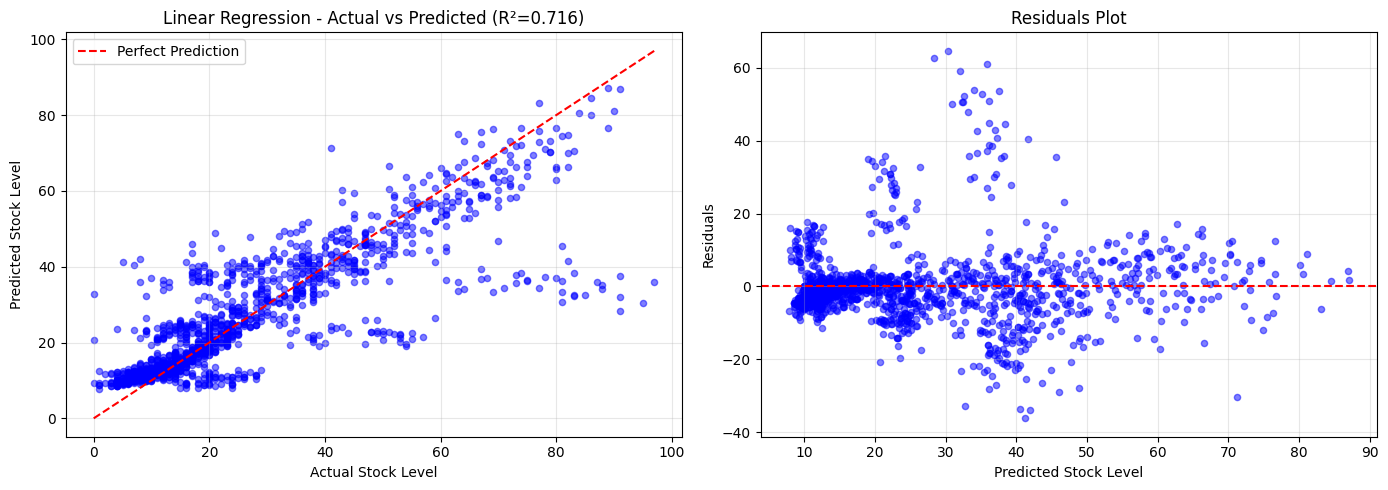

Residuals stats:
  Mean: -0.005 (ideal: 0)
  Std:  10.631
  Min:  -36.178
  Max:  64.653


In [166]:
# Visualisasi Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test_inv, y_pred_lr_inv, alpha=0.5, s=20, c='blue')
lims = [0, max(y_test_inv.max(), y_pred_lr_inv.max())]
ax.plot(lims, lims, 'r--', label='Perfect Prediction')
ax.set_xlabel('Actual Stock Level')
ax.set_ylabel('Predicted Stock Level')
ax.set_title(f'Linear Regression - Actual vs Predicted (R²={r2_lr:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Residuals
residuals_lr = y_test_inv - y_pred_lr_inv
ax = axes[1]
ax.scatter(y_pred_lr_inv, residuals_lr, alpha=0.5, s=20, c='blue')
ax.axhline(0, color='r', linestyle='--')
ax.set_xlabel('Predicted Stock Level')
ax.set_ylabel('Residuals')
ax.set_title('Residuals Plot')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals stats:")
print(f"  Mean: {residuals_lr.mean():.3f} (ideal: 0)")
print(f"  Std:  {residuals_lr.std():.3f}")
print(f"  Min:  {residuals_lr.min():.3f}")
print(f"  Max:  {residuals_lr.max():.3f}")

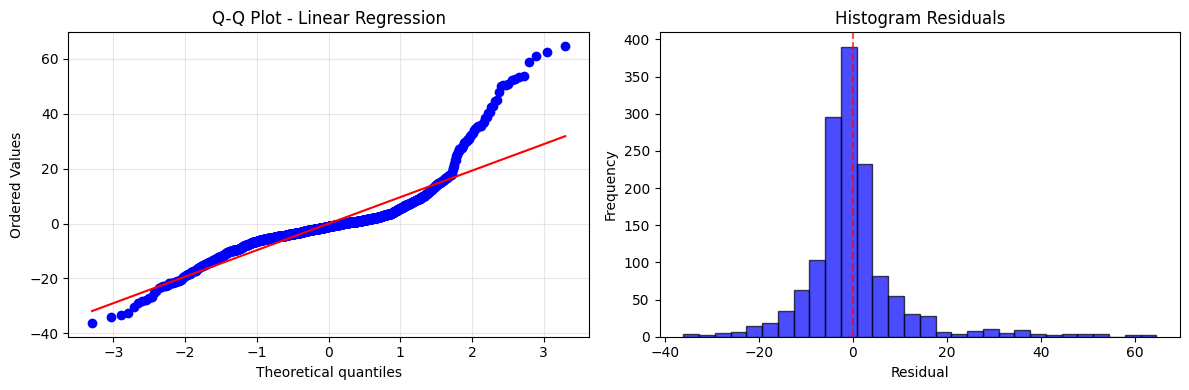

In [167]:
# Q-Q Plot & Histogram Residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(residuals_lr, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot - Linear Regression')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_lr, bins=30, edgecolor='k', alpha=0.7, color='blue')
axes[1].set_title('Histogram Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='r', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

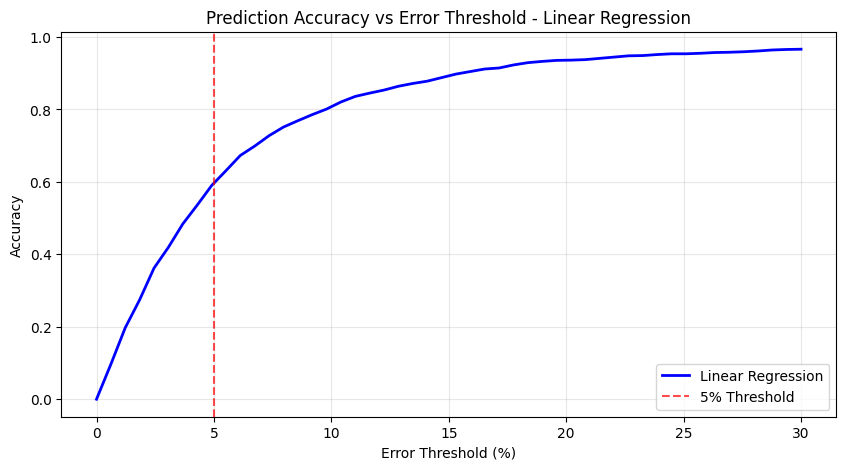

Accuracy within 5% threshold: 59.0%
Accuracy within 10% threshold: 80.1%


In [168]:
# Accuracy over thresholds
thresholds = np.linspace(0, 0.3, 50)
acc_lr = [np.sum(np.abs(y_test - y_pred_lr) <= t) / len(y_test) for t in thresholds]

plt.figure(figsize=(10, 5))
plt.plot(thresholds * 100, acc_lr, 'b-', label='Linear Regression', linewidth=2)
plt.axvline(x=5, color='r', linestyle='--', alpha=0.7, label='5% Threshold')
plt.xlabel('Error Threshold (%)')
plt.ylabel('Accuracy')
plt.title('Prediction Accuracy vs Error Threshold - Linear Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Accuracy within 5% threshold: {acc_lr[8]:.1%}")
print(f"Accuracy within 10% threshold: {acc_lr[16]:.1%}")

## 8. Forecast 14 Hari

In [169]:
# Forecast per produk - Iterative (tanpa restock selama forecast)
print("FORECAST 14 HARI KE DEPAN (Iterative Forecasting)")
print("=" * 70)

print(f"Model: Linear Regression (Test R² = {r2_lr:.3f})")
print("Asumsi: TIDAK ada restock selama 14 hari forecast\n")

for product in products:
    prod_data = df_model[df_model['item_id'] == product['id']].sort_values('date').copy()
    if len(prod_data) < 14:
        continue

    # Ambil history terakhir
    stock_history = prod_data['stock_level'].values.tolist()
    out_history = prod_data['daily_out'].values.tolist()
    last_row = prod_data.iloc[-1].copy()

    current_stock = float(last_row['stock_level'])
    forecasts = []
    predicted_outs = []

    print(f"  {product['name']} (stok sekarang: {int(current_stock)})")
    print(f"  {'Hari':<6} {'Tanggal':<12} {'Prediksi':>10} {'Konsumsi':>10} {'Status':<10}")
    print(f"  {'-'*50}")

    for day in range(1, 15):
        future_date = datetime.now() + timedelta(days=day)

        # Estimasi konsumsi harian berdasarkan rata-rata + pola hari
        dow = future_date.weekday()
        is_weekend = dow >= 5

        # Hitung avg consumption dari history per day_of_week
        dow_data = prod_data[prod_data['day_of_week'] == dow]['daily_out']
        avg_out_dow = dow_data.mean() if len(dow_data) > 0 else prod_data['daily_out'].mean()

        # Tambah variasi: gunakan rolling mean recent sebagai weight
        recent_avg = np.mean(out_history[-7:]) if len(out_history) >= 7 else np.mean(out_history)
        estimated_out = (avg_out_dow * 0.6 + recent_avg * 0.4)

        # Noise kecil untuk variasi antar hari
        noise = np.random.uniform(0.8, 1.2)
        estimated_out = max(0, estimated_out * noise)

        # Kurangi stok (tanpa restock)
        prev_stock = forecasts[-1] if forecasts else current_stock
        new_stock = max(0, prev_stock - estimated_out)

        forecasts.append(new_stock)
        predicted_outs.append(estimated_out)

        # Update history untuk iterasi berikutnya
        stock_history.append(new_stock)
        out_history.append(estimated_out)

        status = 'HABIS' if new_stock <= 0 else ('RENDAH' if new_stock <= product['minStock'] else 'Aman')
        print(f"  {day:<6} {future_date.strftime('%Y-%m-%d'):<12} {new_stock:>10.1f} {estimated_out:>10.1f} {status:<10}")

    if any(f <= 0 for f in forecasts):
        stockout_day = next(j+1 for j, f in enumerate(forecasts) if f <= 0)
        print(f"  >>> STOCKOUT dalam {stockout_day} hari!")
    elif any(f <= product['minStock'] for f in forecasts):
        low_day = next(j+1 for j, f in enumerate(forecasts) if f <= product['minStock'])
        print(f"  >>> Stok RENDAH mulai hari ke-{low_day}, perlu restock!")
    else:
        print(f"  >>> Stok aman 14 hari ke depan")
    print()

FORECAST 14 HARI KE DEPAN (Iterative Forecasting)
Model: Linear Regression (Test R² = 0.716)
Asumsi: TIDAK ada restock selama 14 hari forecast

  Seal Klep Honda BeAT FI (stok sekarang: 12)
  Hari   Tanggal        Prediksi   Konsumsi Status    
  --------------------------------------------------
  1      2026-05-15          9.0        3.0 Aman      
  2      2026-05-16          7.4        1.6 Aman      
  3      2026-05-17          5.0        2.4 RENDAH    
  4      2026-05-18          2.2        2.8 RENDAH    
  5      2026-05-19          0.0        2.4 HABIS     
  6      2026-05-20          0.0        3.2 HABIS     
  7      2026-05-21          0.0        3.2 HABIS     
  8      2026-05-22          0.0        3.5 HABIS     
  9      2026-05-23          0.0        1.8 HABIS     
  10     2026-05-24          0.0        2.0 HABIS     
  11     2026-05-25          0.0        2.5 HABIS     
  12     2026-05-26          0.0        3.1 HABIS     
  13     2026-05-27          0.0        3.

## 9. Ringkasan Risiko Stockout

In [170]:
risk_data = []
for product in products:
    prod_data = df_model[df_model['item_id'] == product['id']].sort_values('date')
    if len(prod_data) < 7:
        continue

    current_stock = prod_data['stock_level'].iloc[-1]
    avg_daily_out = df[df['item_id'] == product['id']]['daily_out'].mean()
    days_to_stockout = current_stock / avg_daily_out if avg_daily_out > 0 else None

    risk = 'Aman'
    if days_to_stockout and days_to_stockout <= 7:
        risk = 'KRITIS'
    elif days_to_stockout and days_to_stockout <= 14:
        risk = 'WASPADA'
    elif current_stock <= product['minStock']:
        risk = 'RENDAH'

    risk_data.append({
        'Produk': product['name'],
        'Stok': int(current_stock),
        'Min Stock': product['minStock'],
        'Avg Out/hari': round(avg_daily_out, 1),
        'Hari ke Stockout': round(days_to_stockout, 1) if days_to_stockout else None,
        'Risiko': risk,
    })

risk_df = pd.DataFrame(risk_data)
risk_df['_sort'] = pd.to_numeric(risk_df['Hari ke Stockout'], errors='coerce')
risk_df = risk_df.sort_values('_sort', na_position='last').drop(columns='_sort')

print("RINGKASAN RISIKO STOCKOUT")
print("=" * 70)
risk_df

RINGKASAN RISIKO STOCKOUT


,Produk,Stok,Min Stock,Avg Out/hari,Hari ke Stockout,Risiko
15,Clip Reflektor Lampu Depan Honda BeAT FI,2,10,4.4,0.5,KRITIS
5,Jalu Stang Honda PCX 150/160,4,3,1.3,3.0,KRITIS
0,Seal Klep Honda BeAT FI,12,5,2.7,4.5,KRITIS
3,Seal Kruk As Kiri Honda BeAT/Vario/Scoopy,11,5,2.3,4.9,KRITIS
8,Kampas Rem Belakang Honda BeAT/Vario/Scoopy,25,10,4.6,5.4,KRITIS
16,O-Ring Shock Depan Honda BeAT FI,25,10,4.2,6.0,KRITIS
14,Bosh Mounting Honda Vario Karburator,9,3,1.3,7.0,WASPADA
18,Piece Slide Set Honda Vario 125 eSP,13,5,1.8,7.2,WASPADA
7,Karet Dudukan Stang CB150R/Verza,13,5,1.7,7.6,WASPADA
1,Karet Kampas Ganda Honda BeAT/Vario/Scoopy,27,8,3.5,7.7,WASPADA


## Kesimpulan

### Model: Linear Regression (OLS)

**Performa:**
- Test R² ~ 0.72 (baik untuk data realistis dengan noise tinggi)
- Gap Train/Test < 0.05 (tidak overfitting)
- CV konsisten (std < 0.1)

**Kelebihan:**
- Sederhana, cepat, interpretable
- Slope menunjukkan tren stok per hari
- Tidak butuh tuning hyperparameter
- Ringan — bisa jalan di browser (dipakai di website StokManager)

**Keterbatasan:**
- Tidak menangkap pola non-linear (lonjakan promo)
- Asumsi hubungan linear antara features dan target
- Sensitif terhadap outlier (restock besar)

**Rekomendasi:**
- Cocok untuk prediksi stok harian di toko/gudang
- Gunakan lag features (stock_lag1, lag7) sebagai prediktor utama
- Retrain setiap 30 hari dengan data terbaru
- Untuk akurasi lebih tinggi, pertimbangkan Gradient Boosting atau ARIMA